
<center><font size=10>Health Insurance Premium Prediction</center></font>


<center><p float="center">
  <img src="https://metainvestment.in/images/insurance/health-insurance.webp"width=700></a>


# **Problem Statement**

## Business Context

Health insurance plays a vital role in helping individuals manage medical expenses. Estimating insurance charges accurately is important for both insurance providers and customers, as it supports fair pricing and effective financial planning. Insurance premiums are influenced by several factors, including age, body mass index (BMI), smoking status, number of children, gender, and region.



## Objective

In this project, predictive analytics and machine learning techniques are used to analyze these factors and build a model that estimates insurance charges. By identifying the variables that have the greatest impact on premiums, the model helps improve pricing accuracy and provides valuable insights for decision-making. This approach enables insurance companies to develop fair and data-driven pricing strategies while helping customers better understand the factors that influence their insurance costs

## Data Description


The dataset consists of several key attributes:

* Age – Age of the insured person.

* Sex – Gender of the individual.

* BMI – Body Mass Index of the person.

* Children – Number of dependent children covered by insurance.

* Smoker – Indicates whether the individual is a smoker or not.

* Region – Residential region of the insured person.

* Charges – Annual health insurance charges (target variable).




# **Installing and Importing Necessary Libraries**

In [1]:
# Import libraries for reading and manipulating data
import pandas as pd
# Import library for numerical operations
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Import utilities for performance evaluation
from sklearn.metrics import mean_squared_error, r2_score

# Import utilities for data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# **Loading the Data**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = pd.read_csv('/content/drive/MyDrive/genai/insurance_prediction.csv')


# **Data Overview**

In [5]:
data.shape

(1338, 7)

The dataset consists of 1,338 rows and 7 columns

In [6]:
data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [7]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


- The dataset contains **7 columns** and **1338 rows**, with **no missing values**.
- Data types are as expected:  
  - **Numeric:** `age`, `bmi`, `children`, `charges`  
  - **Categorical:** `sex`, `smoker`, `region`

In [8]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


- Count → Total number of values in the column.
- Mean → Average of all values.
- Std → Measures how much the data is spread.
- Min → Smallest value.
- 25% (1st Quartile - Q1) → 25% of the data is below this value.
- 50% (Median/Q2) → Middle value of the data.
- 75% (3rd Quartile - Q3) → 75% of the data is below this value.
- Max → Largest value

**Observations:**
1. **Age:** The average age is **39.21 years**, with values ranging from **18 to 64**, indicating a broad adult age group.

2. **BMI:** The mean BMI is **30.66**, suggesting that the **average individual is classified as obese**.

3. **Children:** On average, individuals have **about 1 child**, with most having between **0 and 2 children**.

4. **Charges:** The **average medical charge is 13,270.42**, but the high standard deviation indicates **large variability** in healthcare costs.





In [9]:
data.describe(include='object')


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


1. **Gender:** The dataset has a nearly balanced gender distribution, with **male** being slightly more frequent (676 out of 1338).  
2. **Smoking Status:** **Non-smokers** dominate the dataset (1064 entries), which could impact charge predictions.  
3. **Region:** The **southeast** region has the highest number of entries (364), making it the most represented geographic area.

In [10]:
# Identify duplicate rows
duplicate_rows = data[data.duplicated()]

# Print the number of duplicate rows
print(f"Number of duplicate rows: {len(duplicate_rows)}")

# Display the duplicate rows (optional)
duplicate_rows


Number of duplicate rows: 1


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [11]:
data[data.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [12]:
# Drop duplicate rows
data = data.drop_duplicates()

# Print the shape of the DataFrame after removing duplicates
print(f"Shape after removing duplicates: {data.shape}")


Shape after removing duplicates: (1337, 7)


In [13]:
data[data.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges


There were originally 1,338 rows. After removing 1 duplicate record, the dataset now contains 1,337 records.

# **Exploratory Data Analysis**



- Analyze the distribution of numerical features like **age**, **BMI**, and **charges**.
- Examine the balance of categorical features such as **sex**, **smoker**, **region**, and **children**.
- Explore relationships between variables, especially those that may influence insurance charges.




## **Univariate Analysis**

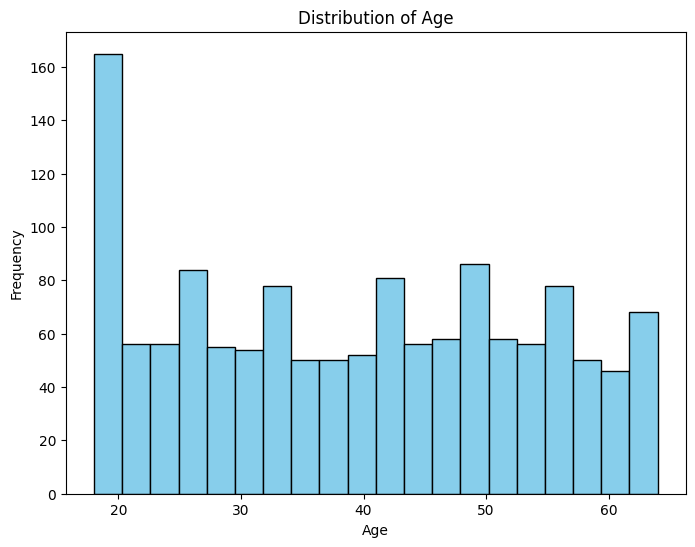

In [14]:
# Create a histogram of the 'age' column
plt.figure(figsize=(8, 6))  # Set the figure size
plt.hist(data['age'], bins=20, color='skyblue', edgecolor='black') # Create histogram with 20 bins
plt.title('Distribution of Age') # Set the title of the histogram
plt.xlabel('Age') # Set the label for the x-axis
plt.ylabel('Frequency') # Set the label for the y-axis
plt.show() # Display the plot


**Observation**:
The histogram shows that age is fairly spread out across the dataset, ranging from 18 to 64, with a roughly uniform distribution and a slightly higher concentration at the youngest ages (18-19). The average age is around 39, and there is no strong skew toward any particular age group.

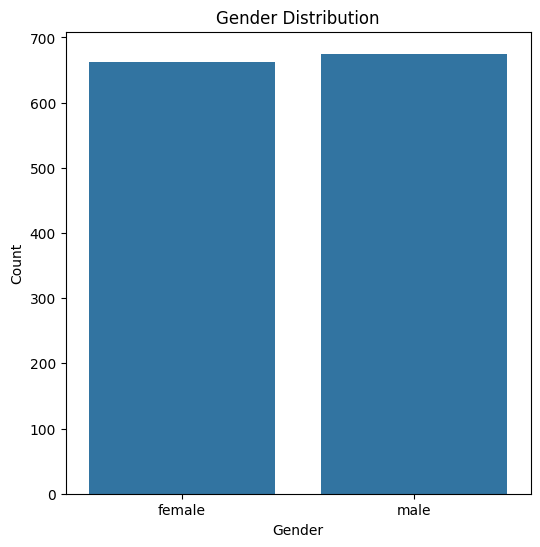

In [15]:
# Check gender distribution to see if the data is balanced.
plt.figure(figsize=(6, 6))
sns.countplot(x='sex', data=data)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


**Observation**:
- We can see that the gender distribution of the population is nearly balanced between males and females, suggesting equal interest in insurance across genders.

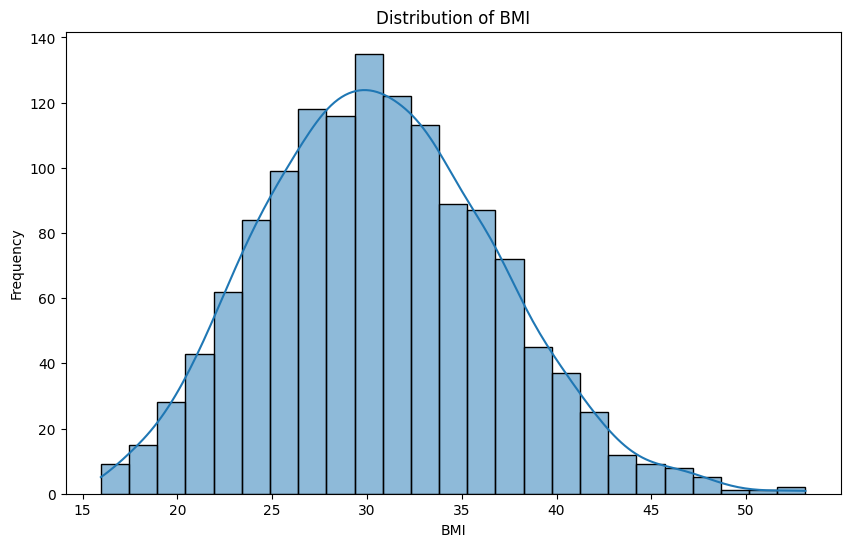

In [16]:
# Analyze how BMI varies across individuals to detect obesity trends.
plt.figure(figsize=(10, 6))
sns.histplot(data['bmi'], kde=True)#Kernel Density Estimation.
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()


**Observations:**
- The data shows that most of the population has a BMI concentrated around 30, as evidenced by the peak of the distribution curve near this value. The bell-shaped curve with a slight right skew suggests a general trend toward higher body mass, with a few individuals having significantly higher BMI values (above 45), indicating the presence of outliers.


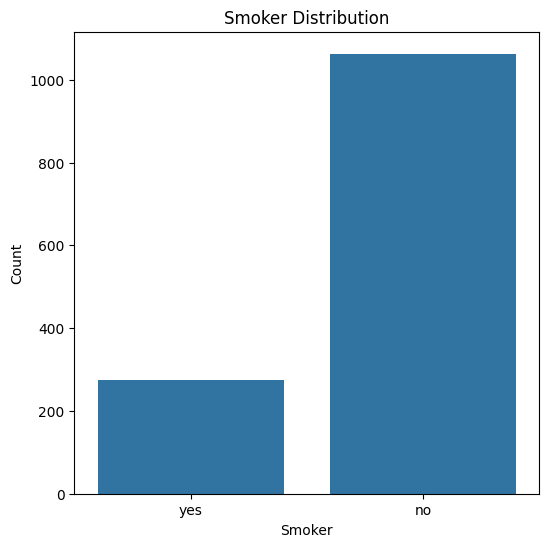

In [17]:
# Visualize the distribution of smokers in the data.
plt.figure(figsize=(6, 6))
sns.countplot(x='smoker', data=data)
plt.title('Smoker Distribution')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.show()


**Observations:**
- The majority of the population appears to be non-smokers.
- This indicates that smoking status could be a key factor in health insurance assessments.

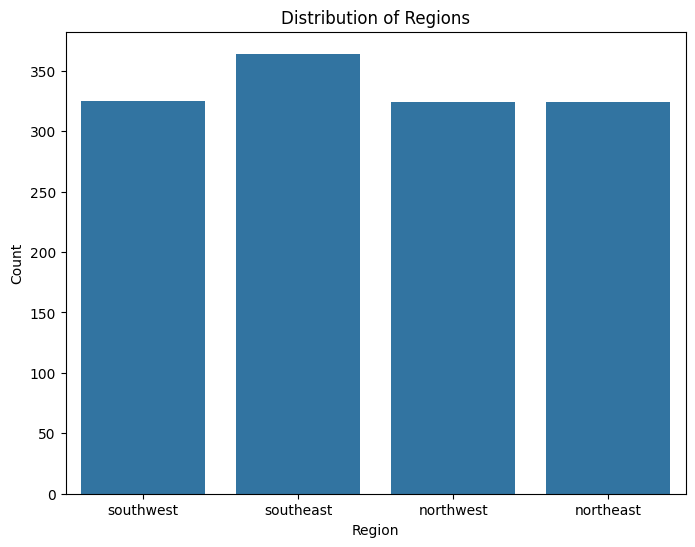

In [18]:
# Visualize the distribution of regions in the data.
plt.figure(figsize=(8, 6))
sns.countplot(x='region', data=data)
plt.title('Distribution of Regions')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()


**Observations:**
- The regional distribution of individuals is relatively balanced, though the southeast has a slightly higher concentration. This suggests potential regional influences that may be important for targeted outreach or service planning.

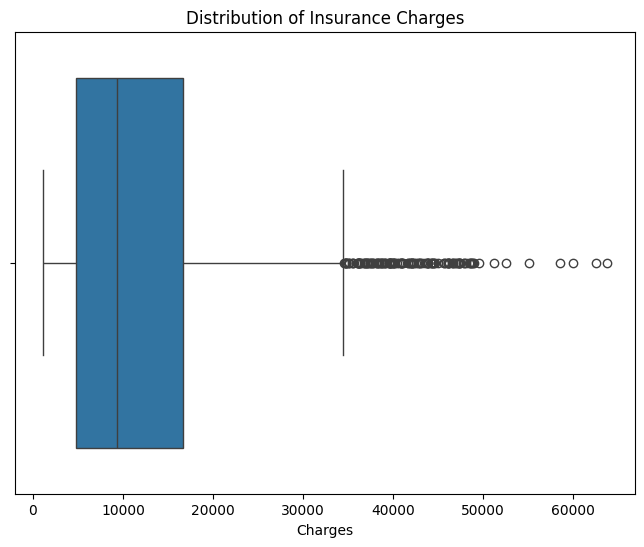

In [19]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='charges', data=data)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')
plt.show()


**Observations:**
- The boxplot shows that **most insurance charges fall below approximately 20,000**, with the **median around 9,000**. However, there are a **significant number of outliers** beyond 35,000, indicating that some individuals incur **very high medical costs**. This right-skewed distribution suggests a need for special attention to these high-cost cases when building predictive models or setting premium strategies.

## **Bivariate Analysis**

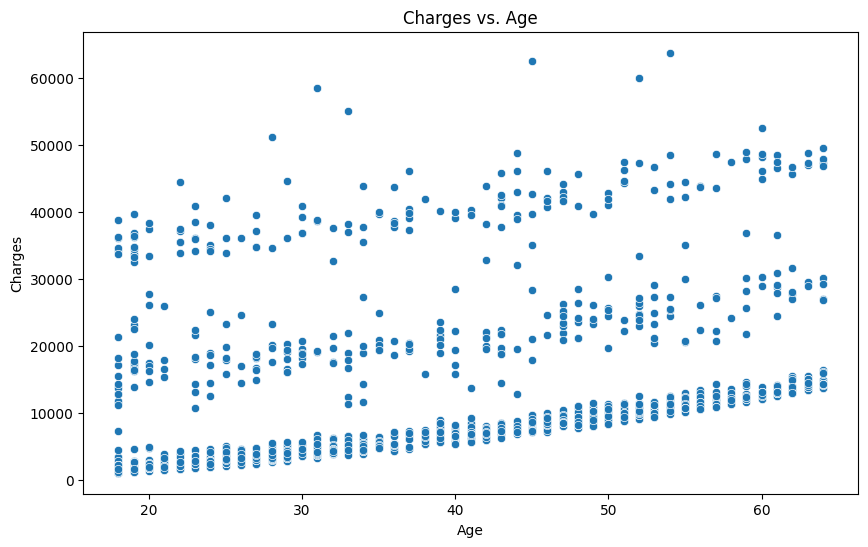

In [20]:
# Create a scatter plot to visualize the relationship between age and charges.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', data=data)
plt.title('Charges vs. Age')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()


**Observations:**
- Insurance charges generally rise with age, indicating a positive correlation where older individuals tend to incur higher costs.
- The chart suggests the presence of three distinct clusters, possibly indicating different insurance plan

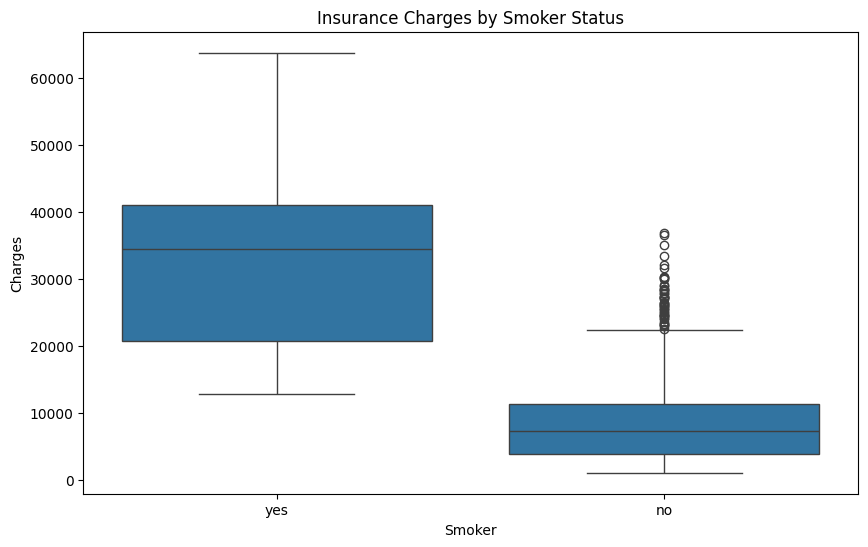

In [21]:
# Compare charges for smokers vs. non-smokers
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title('Insurance Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()


**Observations:**
- The boxplot reveals a **significant difference in insurance charges between smokers and non-smokers**.
- Smokers tend to incur **much higher medical charges**, with a median above 30,000, compared to non-smokers whose median is below 10,000.
- Additionally, the **spread of charges is much wider** for smokers, indicating more variability and higher risk.
- This strong contrast suggests that smoking status is a **critical factor** in determining insurance pricing.

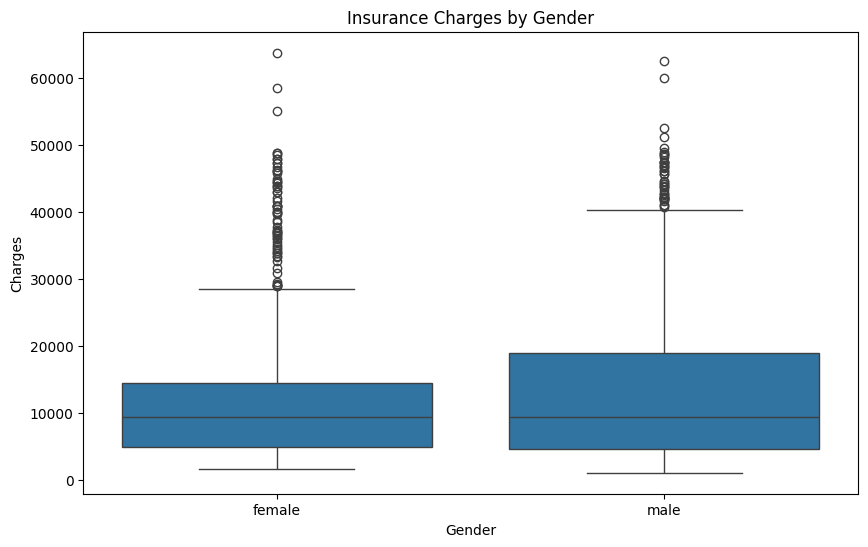

In [22]:
# Analyze if gender affects charges.
plt.figure(figsize=(10, 6))
sns.boxplot(x='sex', y='charges', data=data)
plt.title('Insurance Charges by Gender')
plt.xlabel('Gender')
plt.ylabel('Charges')
plt.show()


**Observations:**
- The box plot shows that males generally face higher and more variable insurance charges than females, suggesting gender may influence insurance pricing.
- This also prompts further investigation into whether other factors like **smoking status** or **BMI** are disproportionately associated with gender, which could be indirectly influencing the observed differences.

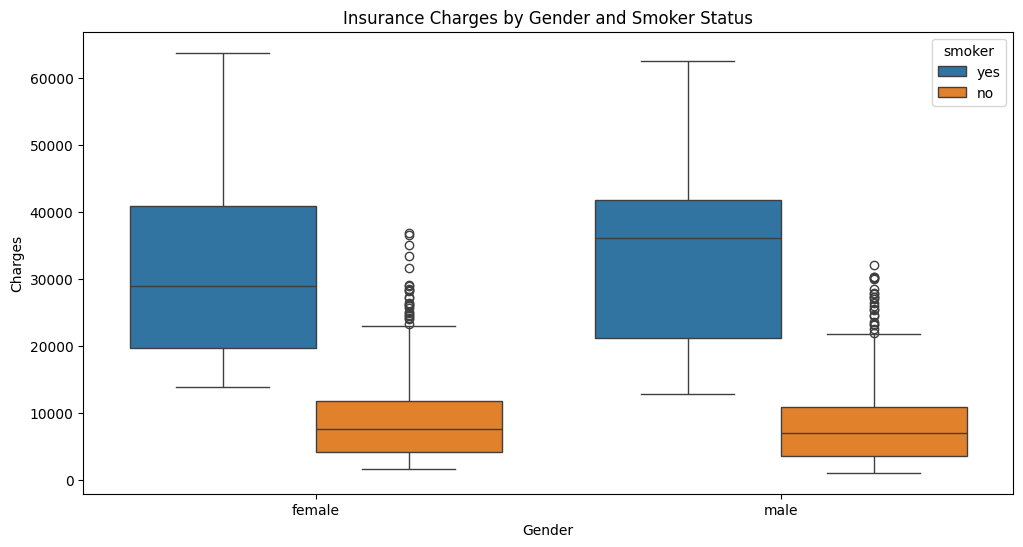

In [23]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='sex', y='charges', hue='smoker', data=data)
plt.title('Insurance Charges by Gender and Smoker Status')
plt.xlabel('Gender')
plt.ylabel('Charges')
plt.show()


**Observations:**
- **Smokers** (both male and female) clearly have **significantly higher insurance charges** compared to non-smokers.
- Among **smokers**, **males** tend to have **slightly higher median charges** than females.
- For **non-smokers**, the distribution is similar across genders, but **male non-smokers show slightly more variability** in charges.


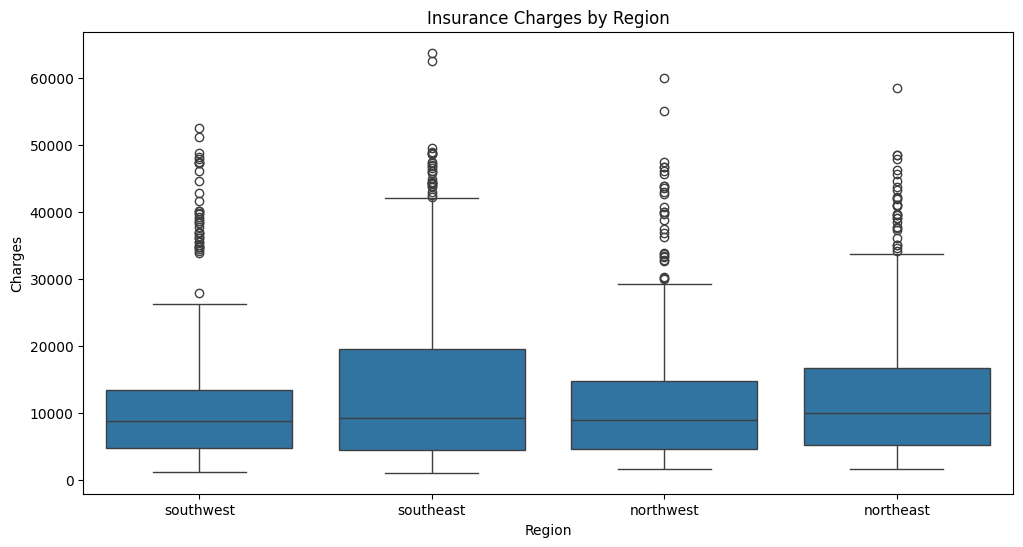

In [24]:
# Analyze regional differences in charges.
plt.figure(figsize=(12, 6))
sns.boxplot(x='region', y='charges', data=data)
plt.title('Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()


**Observations:**
- The boxplot shows that insurance charges are fairly consistent across regions, with **similar medians around 10,000**. However, the **Southeast region** stands out with the **widest spread (~15,000)** and a greater number of high-value outliers, suggesting more variability in charges there. Overall, region may not be a strong predictor of insurance cost, but the Southeast might warrant closer examination due to its higher dispersion.

**correlation heatmap**, which shows how strongly numerical variables are related to each other.

- The values range from **-1 to 1**:
  - **1** means a **perfect positive relationship** (as one goes up, the other goes up).
  - **0** means **no relationship**.
  - **-1** means a **perfect negative relationship** (as one goes up, the other goes down).


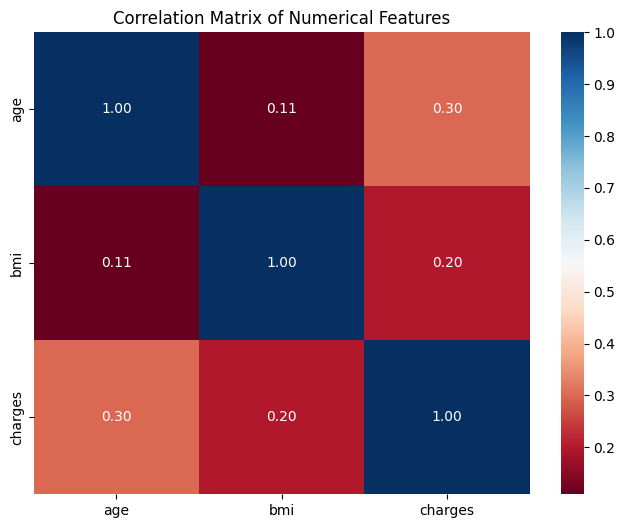

In [25]:
# Create a correlation matrix for numerical features
numerical_cols = ['age', 'bmi', 'charges']
correlation_matrix = data[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


**Observatios:**

- **Age vs Charges (0.30)**:  
   There’s a **moderate positive correlation**. This means that as people get older, their insurance charges tend to increase.

- **BMI vs Charges (0.20)**:  
   There’s a **weak positive correlation**. Higher BMI might lead to higher insurance charges, but the relationship isn't very strong.

- **Age vs BMI (0.11)**:  
   Almost **no correlation** — a person’s age doesn't really tell us much about their BMI.


# **Data Preprocessing**

### Encode the Data

In [26]:
data = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)


In [27]:
data.head(10)

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0
5,31,25.740,0,3756.62160,0,0,0,1,0
6,46,33.440,1,8240.58960,0,0,0,1,0
7,37,27.740,3,7281.50560,0,0,1,0,0
8,37,29.830,2,6406.41070,1,0,0,0,0
9,60,25.840,0,28923.13692,0,0,1,0,0


### Train Test Split

In [28]:
# Split data into features (X) and target (y)
X = data.drop('charges', axis=1)
y = data['charges']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [29]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (935, 8)
X_test shape: (402, 8)
y_train shape: (935,)
y_test shape: (402,)


The training and testing datasets are properly split, with approximately 70% of the data used for training and 30% for testing.

# **Model Building**

## Model Evaluation Criterion



In health insurance charge prediction, the model may predict values that are either lower or higher than the actual insurance charges. Underestimating the charges can reduce the company's revenue, while overestimating them may result in higher premiums for customers.

To assess the performance of the prediction model, two important evaluation metrics are considered:

* **R² Score (Coefficient of Determination):** Indicates how well the model explains the variation in insurance charges. A higher R² value represents better predictive performance.
* **Mean Squared Error (MSE):** Measures the average squared difference between the actual and predicted charges. A lower MSE value indicates more accurate predictions.

Therefore, the objective is to **maximize the R² score** while **minimizing the MSE**, ensuring that the model produces accurate and reliable insurance charge predictions.


## Model Building

With the data preprocessed and ready, we begin our modeling phase using **Linear Regression**, a foundational and interpretable algorithm for predicting continuous outcomes.

Linear Regression assumes a linear relationship between the input features and the target variable in this case, **insurance charges**. It attempts to fit the best possible straight line through the data that minimizes the difference between the predicted and actual values.

**Model Training**

We train the linear regression model on our training dataset, allowing it to learn the relationship between the independent variables (like age, BMI, smoker status, etc.) and the dependent variable (charges).


In [30]:
# Create a blank DataFrame named model_eval_results to store the performance results of different models on the training and testing sets.

model_eval_results = pd.DataFrame(columns=['Model', 'Train_MSE', 'Train_R2', 'Test_MSE', 'Test_R2'])

### Model 1

In the first model, we use only the `age` feature

In [31]:
# Define features (X) and target (y) for Model 1 (Age only)
X_train_m1 = X_train[['age']]
X_test_m1 = X_test[['age']]

# Initialize and train the Linear Regression model
model_1 = LinearRegression()
model_1.fit(X_train_m1, y_train)

LinearRegression()

In [32]:
print(f'Linear Regression Equation: Charges = {model_1.intercept_:.2f} + ({model_1.coef_[0]:.2f} * Age)')

Linear Regression Equation: Charges = 3718.81 + (238.82 * Age)


- Based on the above equation, we can say that insurance premium charges increase as the age of the customer increases.

- It's important to note that it's important to check if the assumptions of linear regression are satisfied before we can make a proper inference from the model coefficients.
    - While the assumptions are out of the scope of the program, you can refer to the reference material of the week in case you're interested in exploring further.

In [33]:
# Predict on training and testing data
y_train_pred_m1 = model_1.predict(X_train_m1)
y_test_pred_m1 = model_1.predict(X_test_m1)

# Calculate MSE and R2 for training data
train_mse_m1 = mean_squared_error(y_train, y_train_pred_m1)
train_r2_m1 = r2_score(y_train, y_train_pred_m1)

# Calculate MSE and R2 for testing data
test_mse_m1 = mean_squared_error(y_test, y_test_pred_m1)
test_r2_m1 = r2_score(y_test, y_test_pred_m1)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 1 (Age Only)', train_mse_m1, train_r2_m1, test_mse_m1, test_r2_m1]

# Display the results
model_eval_results


,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985


- The error is high and the R-squared value is low for both the training and testing datasets, indicating poor model performance and underfitting.
- This is likely due to the use of only a single feature and a simple linear model.

### Model 2

In the second model, we use the 'age' and 'bmi' numerical features to train a multiple linear regression model, and evaluate how well the model performs.

In [34]:
# Define features (X) and target (y) for Model 2 (Age and BMI)
X_train_m2 = X_train[['age', 'bmi']]
X_test_m2 = X_test[['age', 'bmi']]

# Initialize and train the Linear Regression model
model_2 = LinearRegression()
model_2.fit(X_train_m2, y_train)

LinearRegression()

In [35]:
print(f'Linear Regression Equation: Charges = {model_2.intercept_:.2f} + ({model_2.coef_[0]:.2f} * Age) + ({model_2.coef_[1]:.2f} * BMI)')


Linear Regression Equation: Charges = -3641.79 + (227.40 * Age) + (254.94 * BMI)


Based on the equation, insurance charges increase as Age and BMI increase, assuming the other variable remains constant. These conclusions are valid only if the assumptions of linear regression are satisfied.

In [36]:
# Predict on training and testing data
y_train_pred_m2 = model_2.predict(X_train_m2)
y_test_pred_m2 = model_2.predict(X_test_m2)

# Calculate MSE and R2 for training data
train_mse_m2 = mean_squared_error(y_train, y_train_pred_m2)
train_r2_m2 = r2_score(y_train, y_train_pred_m2)

# Calculate MSE and R2 for testing data
test_mse_m2 = mean_squared_error(y_test, y_test_pred_m2)
test_r2_m2 = r2_score(y_test, y_test_pred_m2)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 2 (Age and BMI)', train_mse_m2, train_r2_m2, test_mse_m2, test_r2_m2]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338


- The error has reduced slightly, but is still high, and the R-squared value is low for both the training and testing data, indicating that the model is still performing poorly and **underfitting**.


### Model 3

Now, we use the whole dataset, including both numerical and categorical features, to build our multiple linear regression model, and see how the model performs with all available information.

In [37]:
# Initialize and train the Linear Regression model on the whole data
model_3 = LinearRegression()
model_3.fit(X_train, y_train)

LinearRegression()

In [38]:
# Construct the equation string
equation = f'Charges = {model_3.intercept_:.2f}'
for i, col in enumerate(X_train.columns):
    equation += f' + ({model_3.coef_[i]:.2f} * {col})'

print(f'Linear Regression Equation: {equation}')

Linear Regression Equation: Charges = -11516.78 + (251.25 * age) + (328.38 * bmi) + (522.16 * children) + (-111.91 * sex_male) + (22874.45 * smoker_yes) + (-465.75 * region_northwest) + (-936.10 * region_southeast) + (-765.58 * region_southwest)


In [39]:
# Predict on training and testing data
y_train_pred_m3 = model_3.predict(X_train)
y_test_pred_m3 = model_3.predict(X_test)

# Calculate MSE and R2 for training data
train_mse_m3 = mean_squared_error(y_train, y_train_pred_m3)
train_r2_m3 = r2_score(y_train, y_train_pred_m3)

# Calculate MSE and R2 for testing data
test_mse_m3 = mean_squared_error(y_test, y_test_pred_m3)
test_r2_m3 = r2_score(y_test, y_test_pred_m3)

# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 3 (All Features)', train_mse_m3, train_r2_m3, test_mse_m3, test_r2_m3]

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338
2,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436


- The training and testing R-squared values are close (0.736 and 0.772), with MSE values similarly close, indicating the model is generalizing well, **not overfitting**, and performing well on unseen data.

## Model Comparison and Final Model Selection

In [40]:
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338
2,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436




* **Model 1 (Age)** uses only a single feature and performs the worst, with a very high error and low R² values.
* **Model 2 (Age + BMI)** slightly improves both error and R², but still underperforms.
* **Model 3 (All Features)** shows a **drastic reduction in error** and a **substantial increase in R²**, indicating that it explains a much higher proportion of the variance in the target variable.

**Therefore, Model 3, which incorporates all available features, is the best performing model. It is selected as the final model due to its significantly better predictive accuracy and model fit.**

# **Prediction on unseen Data**

In [46]:
unseen_data = pd.DataFrame({
    'age': [30, 50, 22],
    'bmi': [25.0, 35.0, 20.0],
    'children': [0, 2, 1],
    'sex_male': [0, 1, 0], # 0 for female, 1 for male
    'smoker_yes': [0, 1, 0], # 0 for no, 1 for yes
    'region_northwest': [0, 0, 1],
    'region_southeast': [0, 1, 0],
    'region_southwest': [1, 0, 0]
})

# Ensure the columns are in the same order as X_train
unseen_data = unseen_data[X_train.columns]

# Predict charges for the unseen data using model_3
unseen_predictions = model_3.predict(unseen_data)

print("\n--- Unseen Data with Predicted Charges ---")
unseen_data_with_predictions = unseen_data.copy()
unseen_data_with_predictions['predicted_charges'] = unseen_predictions
display(unseen_data_with_predictions)


--- Unseen Data with Predicted Charges ---


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,predicted_charges
0,30,25.0,0,0,0,0,0,1,3464.597654
1,50,35.0,2,1,1,0,1,0,35409.686590
2,22,20.0,1,0,0,1,0,0,634.705448


Observation:

Looking at Model 3's predictions on the 3 unseen records:

- Person 1 (age 30, non-smoker, BMI 25, region southwest) → predicted charge ₹3,464 – this is quite low, mainly because the person is a non-smoker and has a moderate age and BMI.
- Person 2 (age 50, smoker, BMI 35, region southeast) → predicted charge ₹35,409 – this is much higher, primarily driven by smoking status, combined with a higher age and BMI.
- Person 3 (age 22, non-smoker, BMI 20, region northwest) → predicted charge ₹634 – the lowest among the three, since this person is young, non-smoker, and has a low BMI.

# **Conclusion**


The analysis shows that **smoking status, age, and BMI** are the main factors affecting insurance charges, with smoking having the greatest impact. Gender, region, and the number of children have a smaller influence. Overall, the machine learning model successfully predicts health insurance premiums based on individual characteristics.
